1. LECTURA DE DATOS

In [ ]:
#celda 1: IMPORTAR LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Celda 2:
df = pd.read_csv('/content/drive/MyDrive/mineria/adult .csv', na_values='?', skipinitialspace=True, engine='python', on_bad_lines='skip')

In [ ]:
#celda 3: INFORMACIÓN GENERAL

print("EXPLORACIÓN INICIAL DEL DATASET")
print("-"*50)

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

print("\nColumnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

EXPLORACIÓN INICIAL DEL DATASET
--------------------------------------------------
Filas: 32561
Columnas: 15

Columnas:
['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']

Tipos de datos:
age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object


In [ ]:
#celda 4: Primeras filas
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
#celda 5: Últimas filas
df.tail()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32560,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


2. EDA (ANÁLISIS EXPLORATORIO COMPLETO)

In [ ]:
#celda 6: Información detallada
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
#Celda 7: Estadísticas descriptivas
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
#Celda 8: Estadísticas de variables categóricas
df.describe(include='object')

,workclass,education,marital.status,occupation,relationship,race,sex,native.country,income
count,30725,32561,32561,30718,32561,32561,32561,31978,32561
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [ ]:
# celda 9: VALORES NULOS
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


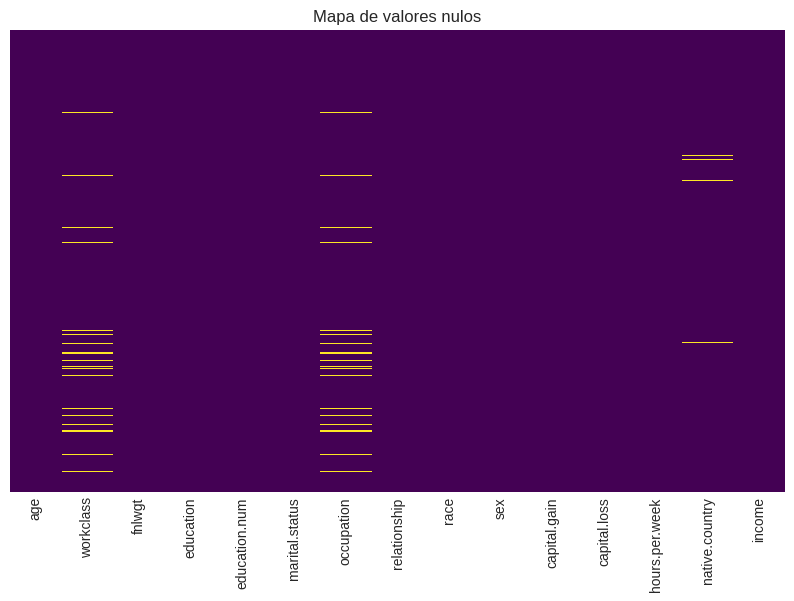

In [ ]:
#Celda 10: valores nulos
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(),
            cbar=False,
            yticklabels=False,
            cmap='viridis')

plt.title("Mapa de valores nulos")
plt.show()

In [ ]:
#celda 11: Valores duplicados
duplicados = df.duplicated().sum()

print(f"Registros duplicados: {duplicados}")

Registros duplicados: 24


In [ ]:
#celda 12: Distribución de variables numéricas
columnas_numericas = df.select_dtypes(include=np.number).columns

columnas_numericas

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')

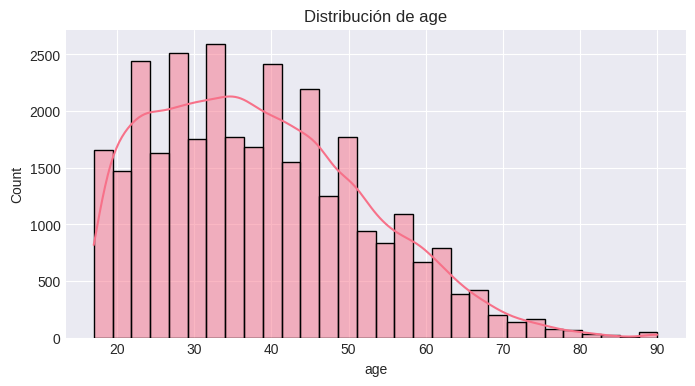

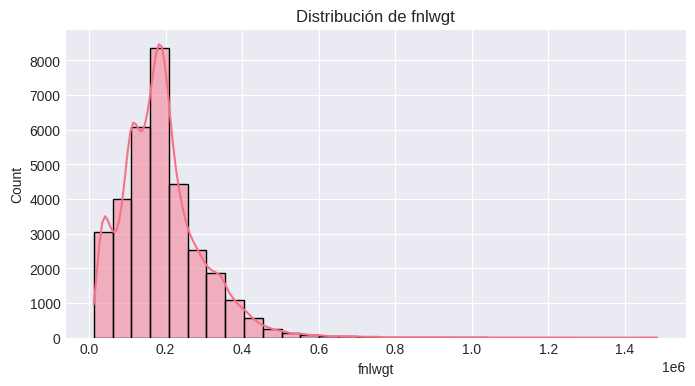

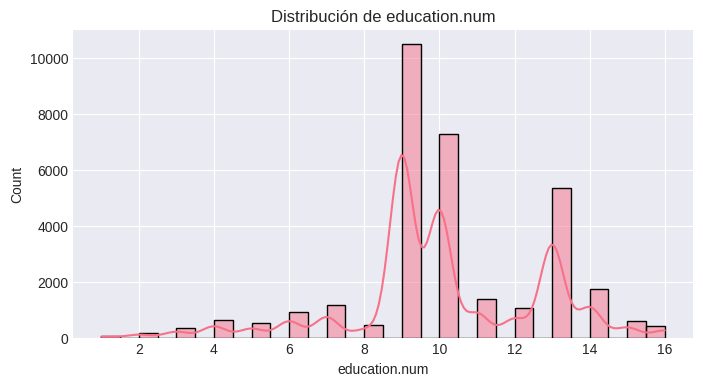

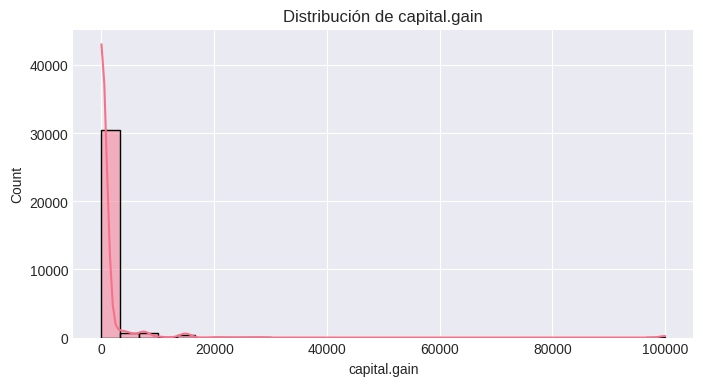

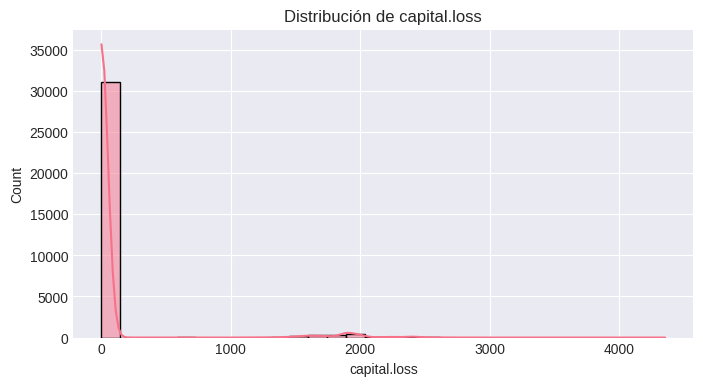

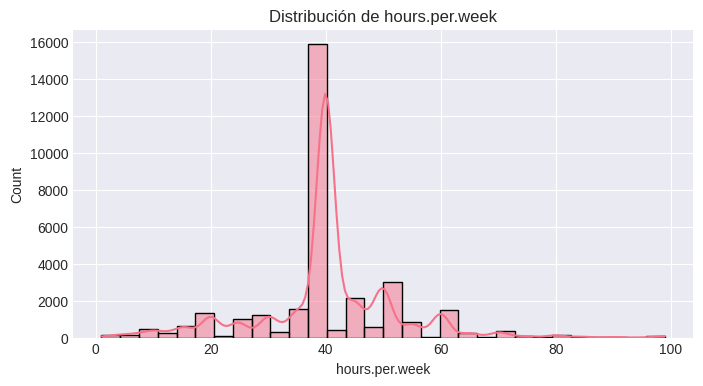

In [ ]:
#Celda 13:
for col in columnas_numericas:

    plt.figure(figsize=(8,4))

    sns.histplot(df[col],
                 kde=True,
                 bins=30)

    plt.title(f'Distribución de {col}')
    plt.show()

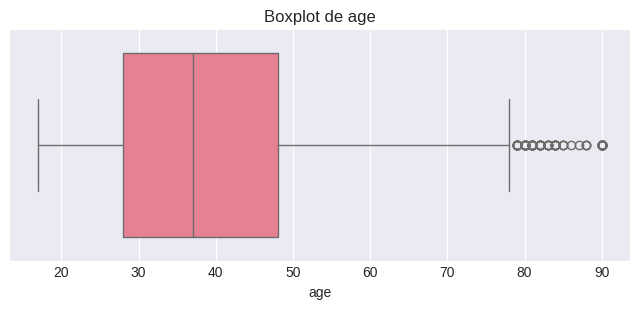

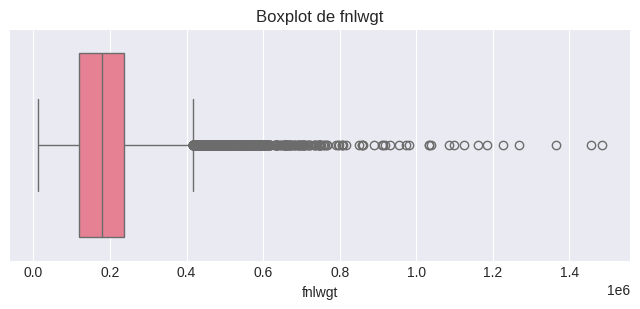

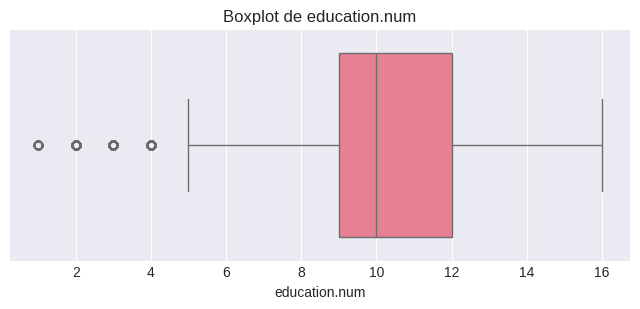

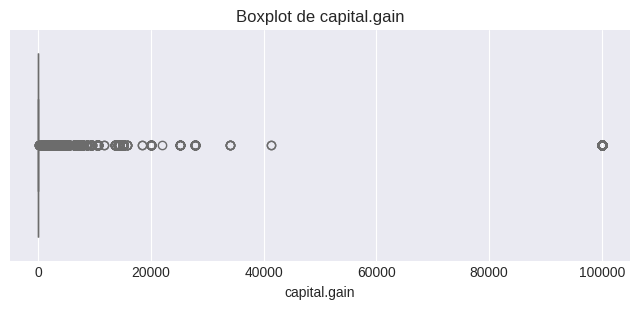

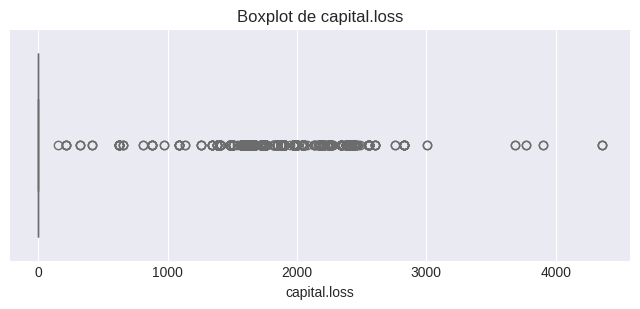

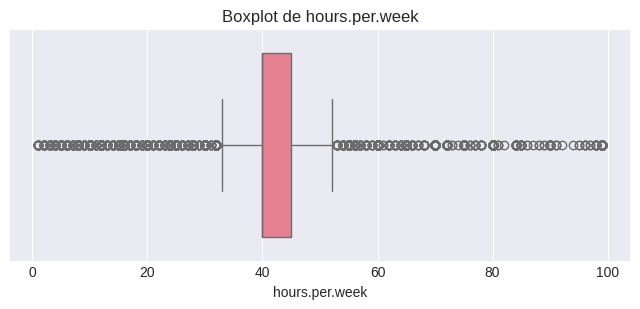

In [ ]:
#celda 14: Boxplots (Outliers)
for col in columnas_numericas:

    plt.figure(figsize=(8,3))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot de {col}')
    plt.show()

In [ ]:
#celda 15: Detección numérica de outliers
for col in columnas_numericas:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_inf = Q1 - 1.5*IQR
    limite_sup = Q3 + 1.5*IQR

    outliers = df[(df[col] < limite_inf) |
                  (df[col] > limite_sup)]

    print(f"{col}: {len(outliers)} outliers")

age: 143 outliers
fnlwgt: 992 outliers
education.num: 1198 outliers
capital.gain: 2712 outliers
capital.loss: 1519 outliers
hours.per.week: 9008 outliers


In [ ]:
#celda 16: Variables categóricas
columnas_categoricas = df.select_dtypes(include='object').columns

columnas_categoricas

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='object')

In [ ]:
#Celda 17:
for col in columnas_categoricas:

    print("\n")
    print("="*50)
    print(col)

    print(df[col].value_counts())



workclass
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64


education
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64


marital.status
marital.status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64


occupation
occupation
Prof-specialty       4140
Craft-repair       

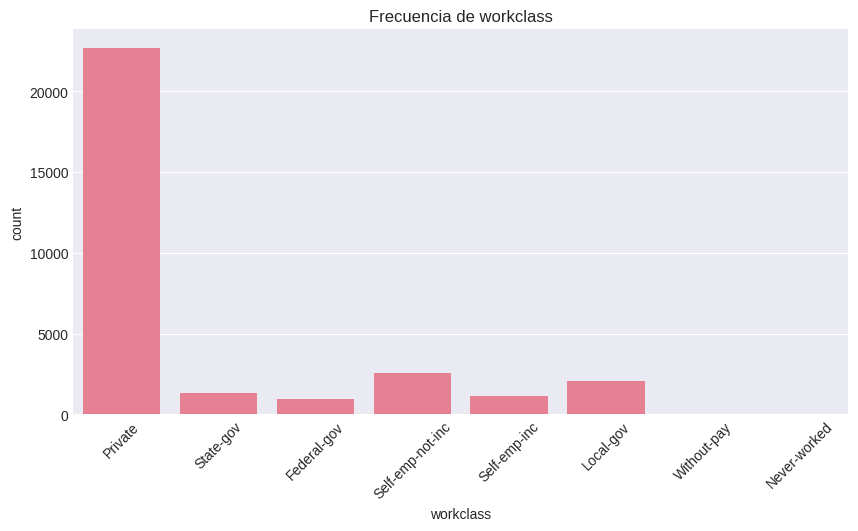

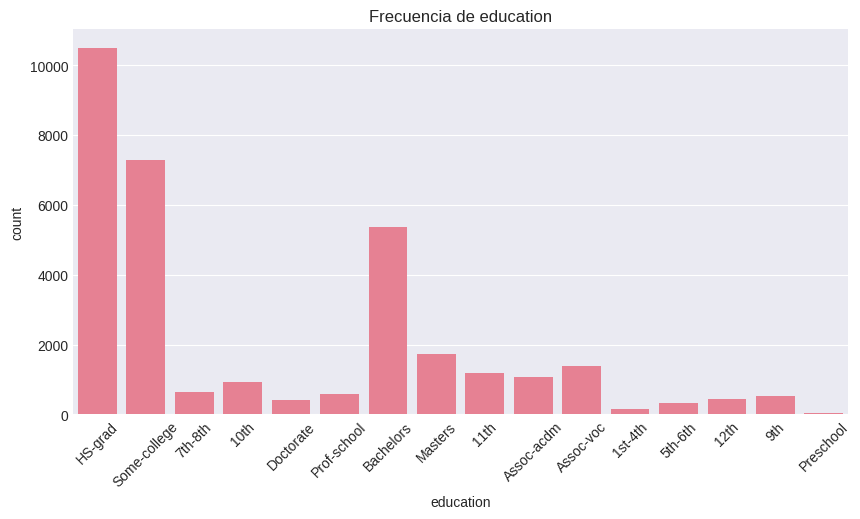

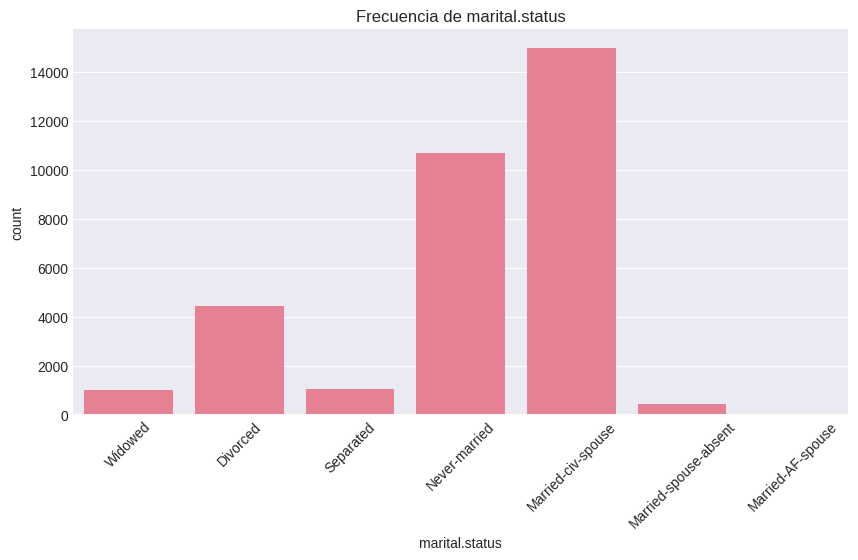

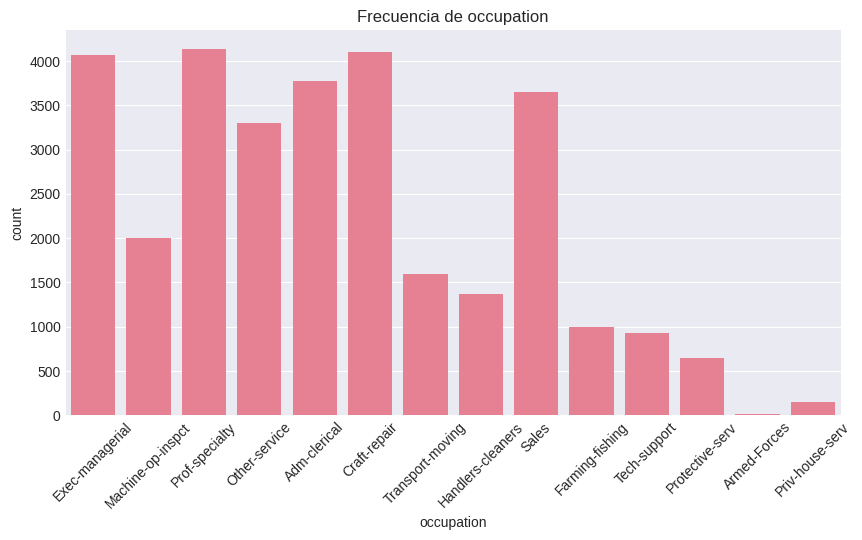

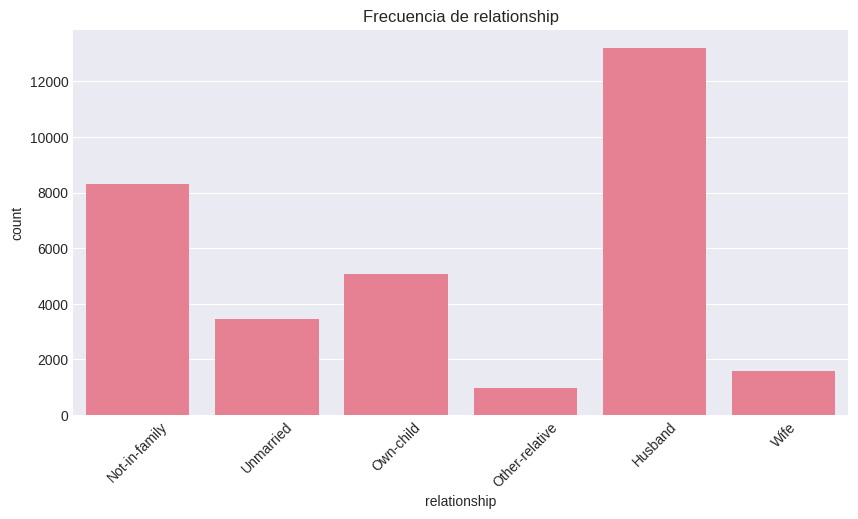

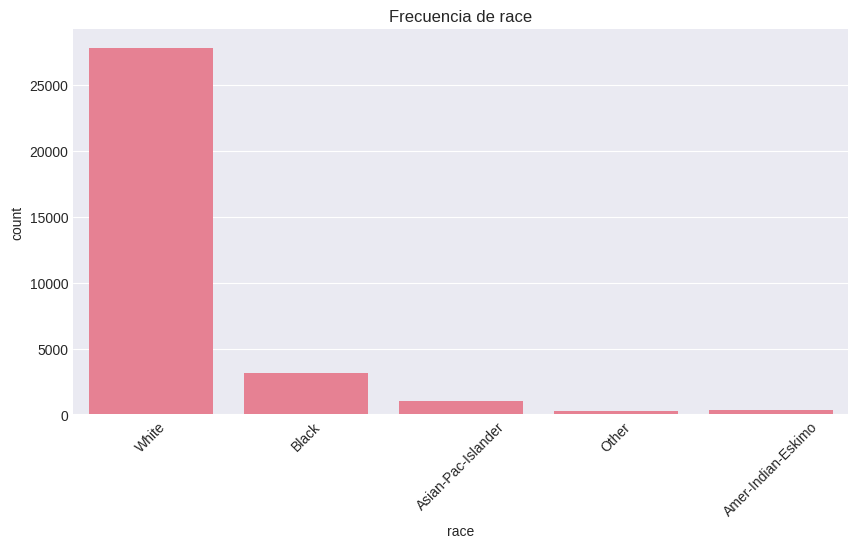

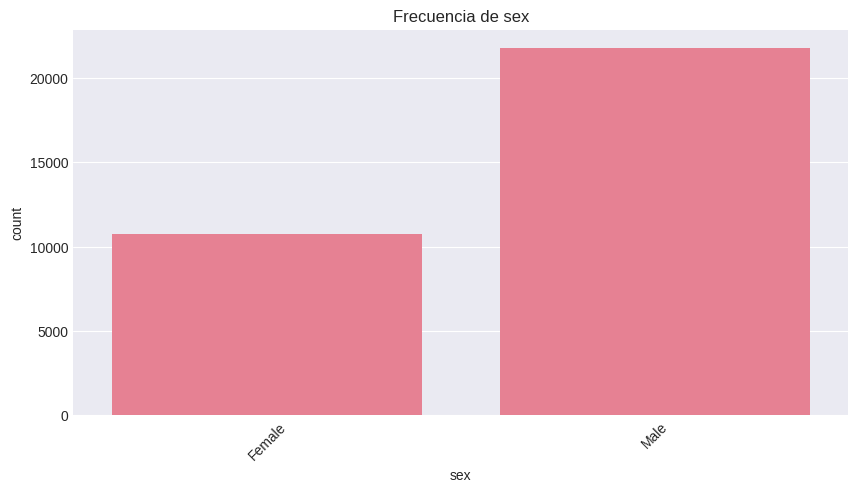

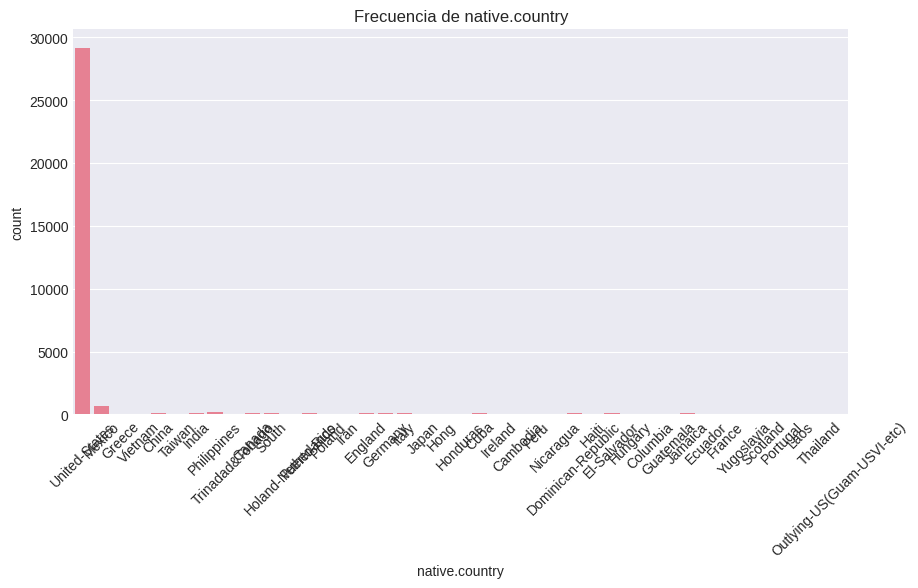

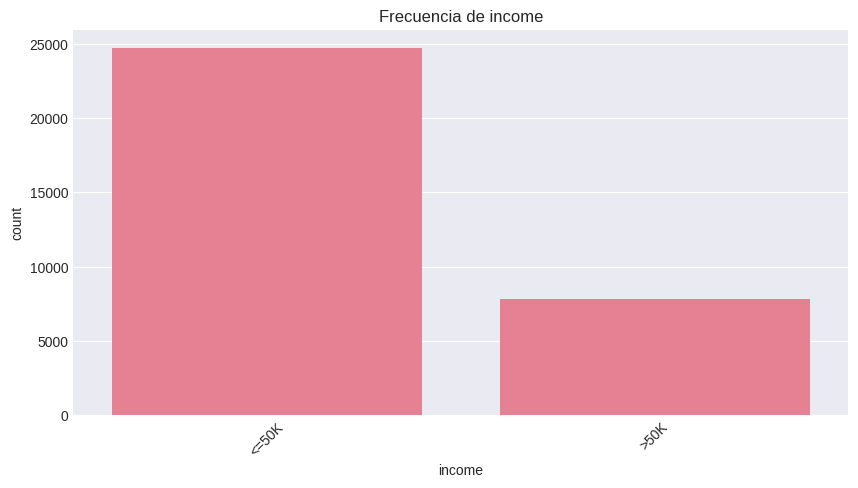

In [ ]:
#Celda 18:
for col in columnas_categoricas:

    plt.figure(figsize=(10,5))

    sns.countplot(data=df,
                  x=col)

    plt.xticks(rotation=45)

    plt.title(f'Frecuencia de {col}')

    plt.show()

In [ ]:
#celda 19: Correlaciones
correlacion = df.corr(numeric_only=True)

correlacion

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
education.num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
capital.gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
capital.loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
hours.per.week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


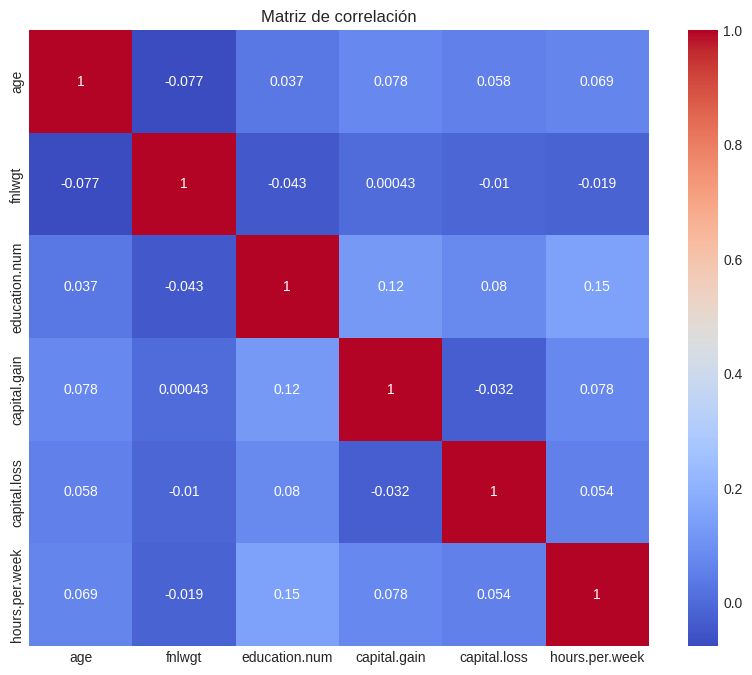

In [ ]:
#Celda 20:
plt.figure(figsize=(10,8))

sns.heatmap(correlacion,
            annot=True,
            cmap='coolwarm')

plt.title("Matriz de correlación")

plt.show()

Relación con variable objetivo

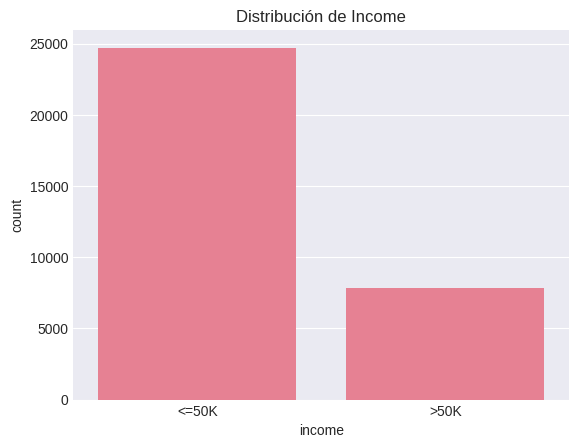

In [ ]:
#celda 21: Celda 21
sns.countplot(data=df,
              x='income')

plt.title("Distribución de Income")
plt.show()

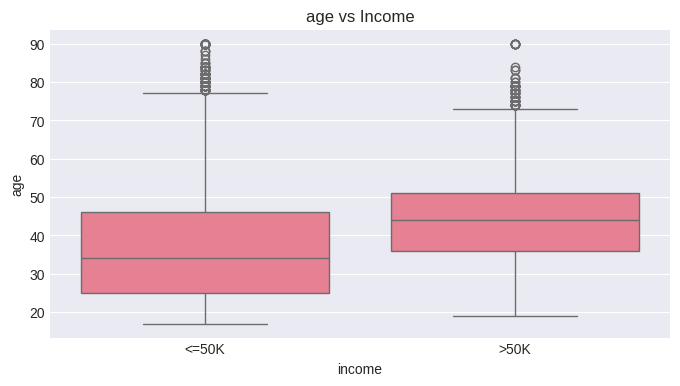

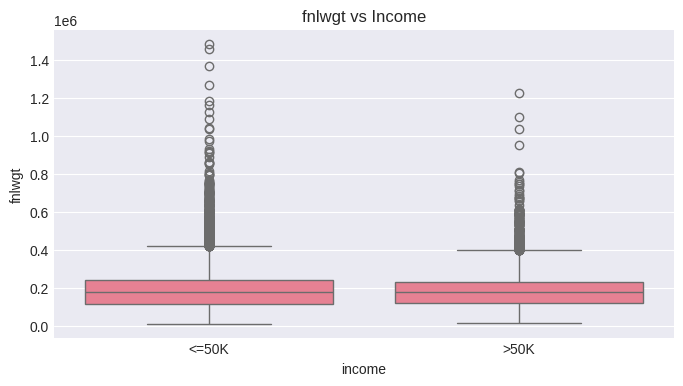

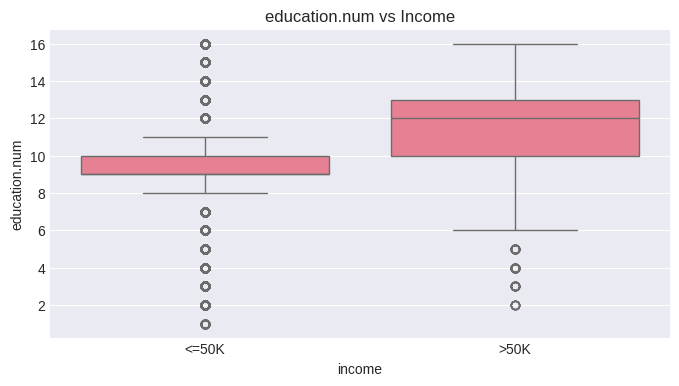

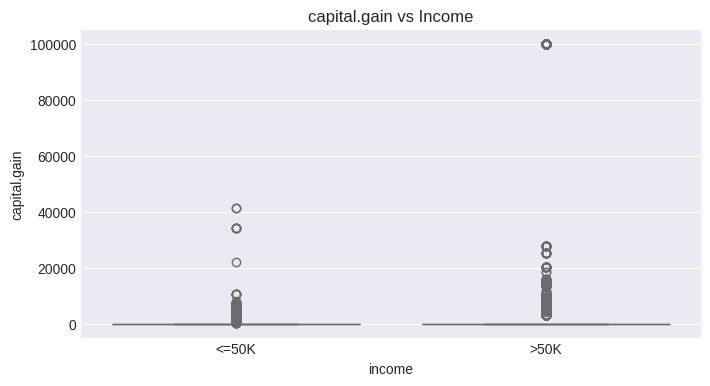

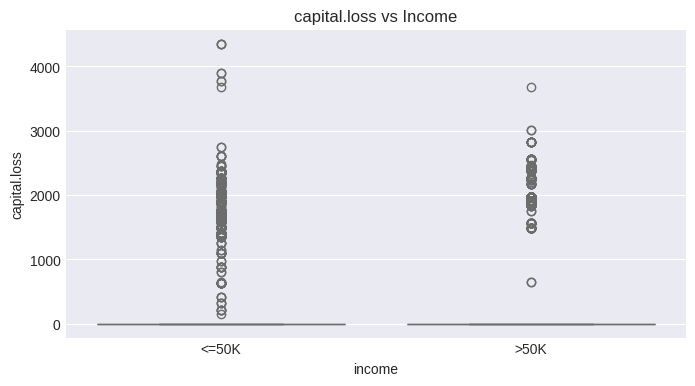

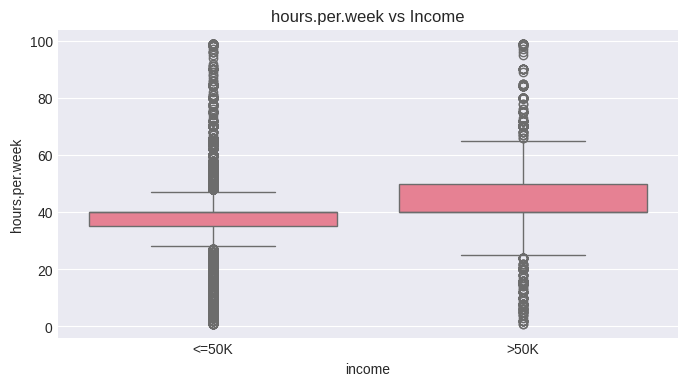

In [ ]:
#Celda 22:
for col in columnas_numericas:

    plt.figure(figsize=(8,4))

    sns.boxplot(data=df,
                x='income',
                y=col)

    plt.title(f'{col} vs Income')

    plt.show()

3. PREPROCESAMIENTO DE DATOS

In [ ]:
#celda 23: Copia
df_pre = df.copy()

In [ ]:
# celda 24: Convertir ? a NaN
df_pre.replace('?', np.nan, inplace=True)

In [ ]:
#celda 25:
df_pre.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
#celda 26: Imputar nulos (Como son variables categóricas.)
for col in ['workclass','occupation','native.country']:

    moda = df_pre[col].mode()[0]

    df_pre[col].fillna(moda, inplace=True)

/tmp/ipykernel_1212/1753317695.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_pre[col].fillna(moda, inplace=True)


In [ ]:
#celda 27:
df_pre.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
#celda 28: Eliminar duplicados
print("Antes:", df_pre.shape)

df_pre.drop_duplicates(inplace=True)

print("Después:", df_pre.shape)

Antes: (32561, 15)
Después: (32537, 15)


In [ ]:
#celda 28: Eliminar columna education
df_pre.drop('education',
            axis=1,
            inplace=True)

In [ ]:
#celda 29: Codificar variable objetivo
df_pre['income'] = df_pre['income'].map({
    '<=50K':0,
    '>50K':1
})

In [ ]:
#celda 30:
df_pre['income'].value_counts()

,count
income,
0,24698
1,7839


In [ ]:
#celda 31: One-Hot Encoding
df_pre = pd.get_dummies(
    df_pre,
    drop_first=True
)

In [ ]:
#celda 32:
df_pre.shape

(32537, 83)

In [ ]:
#celda 33: Escalado (Separar X e y.)
X = df_pre.drop('income', axis=1)

y = df_pre['income']

In [ ]:
#celda 34:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
#celda 35:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,3.770003,-1.067955,-0.420679,-0.145975,10.589625,-0.035664,-0.262201,-0.014669,0.572323,-0.188461,...,-0.033741,-0.059296,-0.019208,-0.049647,-0.039622,-0.023527,-0.024172,0.306973,-0.045425,-0.022181
1,3.183397,-0.539159,-0.420679,-0.145975,10.589625,-1.817516,-0.262201,-0.014669,0.572323,-0.188461,...,-0.033741,-0.059296,-0.019208,-0.049647,-0.039622,-0.023527,-0.024172,0.306973,-0.045425,-0.022181
2,2.010185,-0.035241,-0.031815,-0.145975,10.589625,-0.035664,-0.262201,-0.014669,0.572323,-0.188461,...,-0.033741,-0.059296,-0.019208,-0.049647,-0.039622,-0.023527,-0.024172,0.306973,-0.045425,-0.022181
3,1.130276,-0.468210,-2.364998,-0.145975,9.458380,-0.035664,-0.262201,-0.014669,0.572323,-0.188461,...,-0.033741,-0.059296,-0.019208,-0.049647,-0.039622,-0.023527,-0.024172,0.306973,-0.045425,-0.022181
4,0.177041,0.709415,-0.031815,-0.145975,9.458380,-0.035664,-0.262201,-0.014669,0.572323,-0.188461,...,-0.033741,-0.059296,-0.019208,-0.049647,-0.039622,-0.023527,-0.024172,0.306973,-0.045425,-0.022181


In [ ]:
#celda 36: Dataset final
df_final = X_scaled.copy()

df_final['income'] = y.values

df_final.head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia,income
0,3.770003,-1.067955,-0.420679,-0.145975,10.589625,-0.035664,-0.262201,-0.014669,0.572323,-0.188461,...,-0.059296,-0.019208,-0.049647,-0.039622,-0.023527,-0.024172,0.306973,-0.045425,-0.022181,0
1,3.183397,-0.539159,-0.420679,-0.145975,10.589625,-1.817516,-0.262201,-0.014669,0.572323,-0.188461,...,-0.059296,-0.019208,-0.049647,-0.039622,-0.023527,-0.024172,0.306973,-0.045425,-0.022181,0
2,2.010185,-0.035241,-0.031815,-0.145975,10.589625,-0.035664,-0.262201,-0.014669,0.572323,-0.188461,...,-0.059296,-0.019208,-0.049647,-0.039622,-0.023527,-0.024172,0.306973,-0.045425,-0.022181,0
3,1.130276,-0.468210,-2.364998,-0.145975,9.458380,-0.035664,-0.262201,-0.014669,0.572323,-0.188461,...,-0.059296,-0.019208,-0.049647,-0.039622,-0.023527,-0.024172,0.306973,-0.045425,-0.022181,0
4,0.177041,0.709415,-0.031815,-0.145975,9.458380,-0.035664,-0.262201,-0.014669,0.572323,-0.188461,...,-0.059296,-0.019208,-0.049647,-0.039622,-0.023527,-0.024172,0.306973,-0.045425,-0.022181,0


In [ ]:
#celda 37: Guardar

In [ ]:
df_final.to_csv(
    'adult_preprocesado.csv',
    index=False
)

print("Dataset guardado")

Dataset guardado


**Justificación**

> Durante el EDA se identificó que el conjunto de datos no presentaba valores nulos explícitos; sin embargo, las variables workclass, occupation y native.country contenían registros representados por el carácter '?' que fueron tratados como valores faltantes. Estos fueron imputados utilizando la moda de cada variable. Se eliminaron 24 registros duplicados encontrados. La variable education fue removida debido a su redundancia con education.num. Las variables categóricas fueron transformadas mediante One-Hot Encoding y posteriormente se aplicó una estandarización de las variables numéricas mediante StandardScaler para preparar los datos para modelos de Machine Learning. Los valores extremos observados en variables como capital.gain y capital.loss se conservaron al considerarse información relevante para la predicción del nivel de ingresos.



4. DIVISION DE DATOS  

In [ ]:
#CELDA 38: Importar train_test_split

from sklearn.model_selection import train_test_split

In [ ]:
#CELDA 39: Separar variables predictoras y objetivo
X = df_final.drop('income', axis=1)

y = df_final['income']

print("X:", X.shape)
print("y:", y.shape)

X: (32537, 82)
y: (32537,)


In [ ]:
#CELDA 40: Dividir entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
#CELDA 41: Verificar dimensiones
print("ENTRENAMIENTO")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nPRUEBA")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

ENTRENAMIENTO
X_train: (26029, 82)
y_train: (26029,)

PRUEBA
X_test: (6508, 82)
y_test: (6508,)


In [ ]:
#CELDA 42: Verificar distribución de clases
print("Distribución total")
print(y.value_counts(normalize=True)*100)

print("\nDistribución entrenamiento")
print(y_train.value_counts(normalize=True)*100)

print("\nDistribución prueba")
print(y_test.value_counts(normalize=True)*100)

Distribución total
income
0    75.907428
1    24.092572
Name: proportion, dtype: float64

Distribución entrenamiento
income
0    75.907641
1    24.092359
Name: proportion, dtype: float64

Distribución prueba
income
0    75.906577
1    24.093423
Name: proportion, dtype: float64


In [ ]:
#CELDA 43: Resumen de la división
print("RESUMEN DIVISIÓN DE DATOS")
print("="*50)

print(f"Total registros: {len(df_final)}")
print(f"Entrenamiento: {len(X_train)}")
print(f"Prueba: {len(X_test)}")

print(f"\nPorcentaje entrenamiento: {(len(X_train)/len(df_final))*100:.2f}%")
print(f"Porcentaje prueba: {(len(X_test)/len(df_final))*100:.2f}%")

RESUMEN DIVISIÓN DE DATOS
Total registros: 32537
Entrenamiento: 26029
Prueba: 6508

Porcentaje entrenamiento: 80.00%
Porcentaje prueba: 20.00%


In [ ]:
#CELDA 44: Guardar conjuntos
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Archivos guardados")

Archivos guardados


**informe División de Datos**

> Después del preprocesamiento se realizó la separación de los datos en variables predictoras (X) y variable objetivo (y). Posteriormente se aplicó la técnica Train-Test Split utilizando un 80% de los registros para entrenamiento y un 20% para prueba. Se utilizó el parámetro stratify=y para conservar la distribución original de las clases de la variable objetivo income, evitando sesgos debido al desbalance presente en el conjunto de datos. Además, se estableció random_state=42 para garantizar la reproducibilidad de los resultados.



5. MODELOS DE MACHINE LEARNING

In [ ]:
#CELDA 45: Importar modelos y métricas

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef
)

In [ ]:
#CELDA 46: REGRESIÓN LOGÍSTICA
modelo_lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

modelo_lr.fit(X_train, y_train)

LogisticRegression(max_iter=5000, random_state=42)

In [ ]:
#CELDA 47:
y_pred_lr = modelo_lr.predict(X_test)

In [ ]:
#CELDA 48:
print("RESULTADOS - REGRESIÓN LOGÍSTICA")
print("="*50)

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Precision:",
      precision_score(y_test, y_pred_lr))

print("Recall:",
      recall_score(y_test, y_pred_lr))

print("F1 Score:",
      f1_score(y_test, y_pred_lr))

RESULTADOS - REGRESIÓN LOGÍSTICA
Accuracy: 0.85079901659496
Precision: 0.7344854673998429
Recall: 0.5963010204081632
F1 Score: 0.6582189369940162


In [ ]:
#CELDA 49:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4940
           1       0.73      0.60      0.66      1568

    accuracy                           0.85      6508
   macro avg       0.81      0.76      0.78      6508
weighted avg       0.84      0.85      0.85      6508



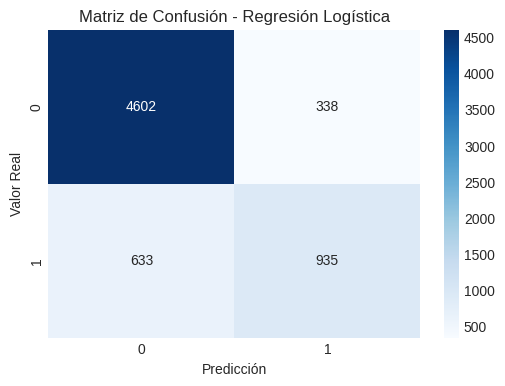

In [ ]:
#CELDA 50:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

MODELO 2: ÁRBOL DE DECISIÓN

In [ ]:
#CELDA 51:
modelo_tree = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

modelo_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [ ]:
#CELDA 52:
y_pred_tree = modelo_tree.predict(X_test)

In [ ]:
#CELDA 53:
print("RESULTADOS - ÁRBOL DE DECISIÓN")
print("="*50)

print("Accuracy:",
      accuracy_score(y_test, y_pred_tree))

print("Precision:",
      precision_score(y_test, y_pred_tree))

print("Recall:",
      recall_score(y_test, y_pred_tree))

print("F1 Score:",
      f1_score(y_test, y_pred_tree))

RESULTADOS - ÁRBOL DE DECISIÓN
Accuracy: 0.8484941610325752
Precision: 0.7130307467057101
Recall: 0.6211734693877551
F1 Score: 0.6639400136332652


In [ ]:
#CELDA 54:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4940
           1       0.71      0.62      0.66      1568

    accuracy                           0.85      6508
   macro avg       0.80      0.77      0.78      6508
weighted avg       0.84      0.85      0.84      6508



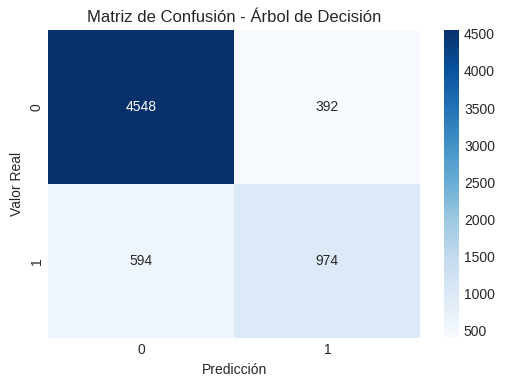

In [ ]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

MODELO 3: RANDOM FOREST

In [ ]:
#CELDA 55:
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
#CELDA 56:
y_pred_rf = modelo_rf.predict(X_test)

In [ ]:
#CELDA 57:
print("RESULTADOS - RANDOM FOREST")
print("="*50)

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

RESULTADOS - RANDOM FOREST
Accuracy: 0.8518746158574063
Precision: 0.7315950920245399
Recall: 0.6084183673469388
F1 Score: 0.6643454038997214


In [ ]:
#CELDA 58:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4940
           1       0.73      0.61      0.66      1568

    accuracy                           0.85      6508
   macro avg       0.81      0.77      0.78      6508
weighted avg       0.85      0.85      0.85      6508



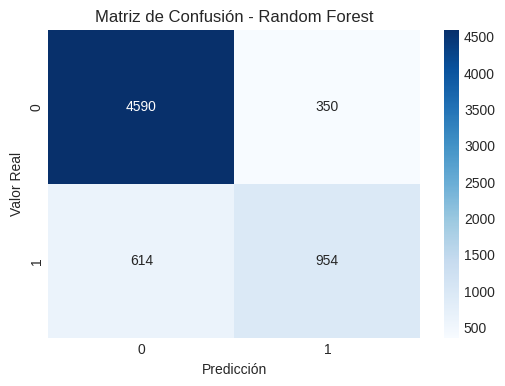

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

In [ ]:
#CELDA 59: COMPARACIÓN DE MODELOS
resultados = pd.DataFrame({
    "Modelo":[
        "Regresión Logística",
        "Árbol de Decisión",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_tree),
        accuracy_score(y_test,y_pred_rf)
    ],

    "Precision":[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_tree),
        precision_score(y_test,y_pred_rf)
    ],

    "Recall":[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_tree),
        recall_score(y_test,y_pred_rf)
    ],

    "F1":[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_tree),
        f1_score(y_test,y_pred_rf)
    ],

    "MCC":[
        matthews_corrcoef(y_test, y_pred_lr),
        matthews_corrcoef(y_test, y_pred_tree),
        matthews_corrcoef(y_test, y_pred_rf)
    ]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1,MCC
0,Regresión Logística,0.850799,0.734485,0.596301,0.658219,0.569114
1,Árbol de Decisión,0.848494,0.713031,0.621173,0.663940,0.568985
2,Random Forest,0.851875,0.731595,0.608418,0.664345,0.574331


In [ ]:
#CELDA 60:
resultados.sort_values(
    by="F1",
    ascending=False
)

,Modelo,Accuracy,Precision,Recall,F1,MCC
2,Random Forest,0.851875,0.731595,0.608418,0.664345,0.574331
1,Árbol de Decisión,0.848494,0.713031,0.621173,0.663940,0.568985
0,Regresión Logística,0.850799,0.734485,0.596301,0.658219,0.569114


MODELO 4: SUPPORT VECTOR MACHINE (SVM)

In [ ]:
#CELDA 62:
from sklearn.svm import SVC

modelo_svm = SVC(random_state=42)

modelo_svm.fit(X_train, y_train)

SVC(random_state=42)

In [ ]:
#CELDA 63:
y_pred_svm = modelo_svm.predict(X_test)

In [ ]:
#CELDA 64:
print("RESULTADOS - SUPPORT VECTOR MACHINE")
print("="*50)

print("Accuracy:",
      accuracy_score(y_test, y_pred_svm))

print("Precision:",
      precision_score(y_test, y_pred_svm))

print("Recall:",
      recall_score(y_test, y_pred_svm))

print("F1 Score:",
      f1_score(y_test, y_pred_svm))

RESULTADOS - SUPPORT VECTOR MACHINE
Accuracy: 0.8437307928703135
Precision: 0.735269000853971
Recall: 0.5491071428571429
F1 Score: 0.628696604600219


In [ ]:
#CELDA 65:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.87      0.94      0.90      4940
           1       0.74      0.55      0.63      1568

    accuracy                           0.84      6508
   macro avg       0.80      0.74      0.76      6508
weighted avg       0.84      0.84      0.84      6508



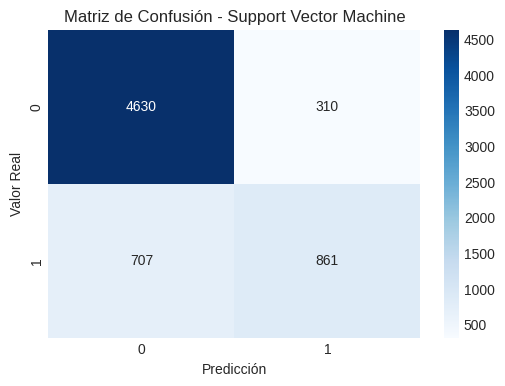

In [ ]:

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matriz de Confusión - Support Vector Machine")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

Comparación de Modelos

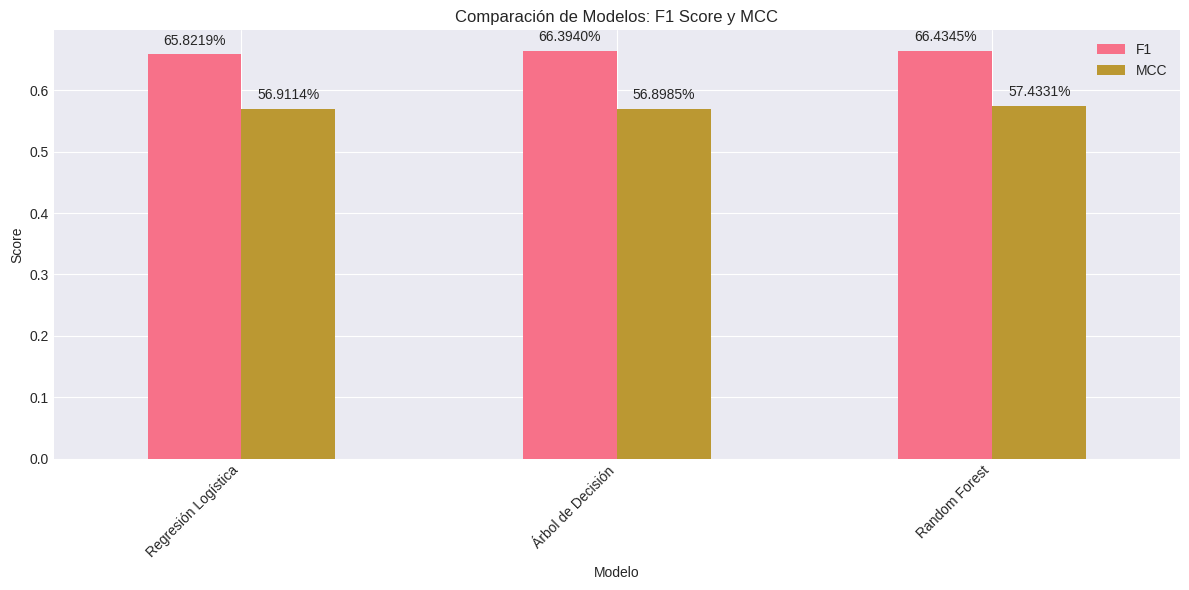

In [ ]:
ax = resultados.set_index("Modelo")[["F1", "MCC"]].plot(
    kind="bar",
    figsize=(12,6) # Adjusted size for two metrics
)

plt.title("Comparación de Modelos: F1 Score y MCC")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')

# Annotate each bar with 4 decimal places as percentages
for container in ax.containers:
    for p in container.patches:
        ax.annotate(f'{p.get_height():.4%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

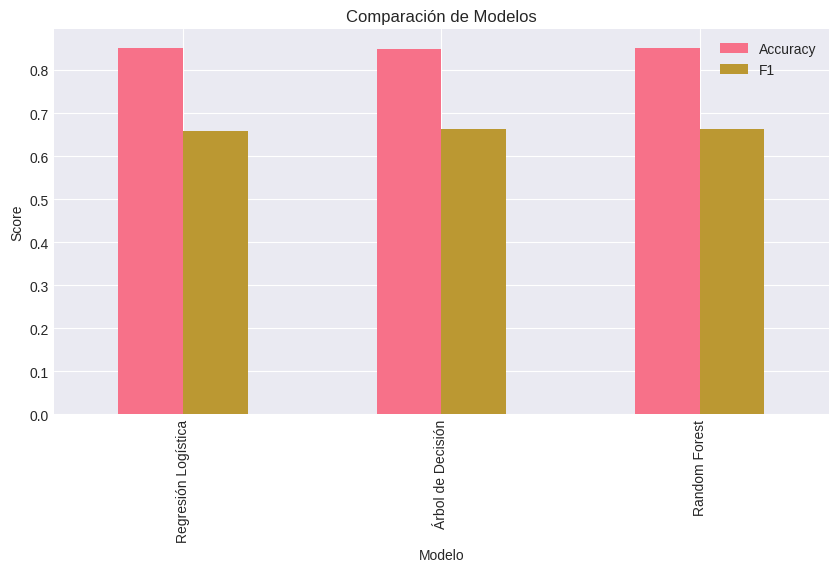

In [ ]:
#CELDA :
resultados.set_index("Modelo")[["Accuracy","F1"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Comparación de Modelos")
plt.ylabel("Score")

plt.show()

In [ ]:
#CELDA 66: COMPARACIÓN DE MODELOS ACTUALIZADA
resultados_actualizados = resultados.copy()

resultados_actualizados.loc[len(resultados_actualizados)] = [
    "Support Vector Machine",
    accuracy_score(y_test, y_pred_svm),
    precision_score(y_test, y_pred_svm),
    recall_score(y_test, y_pred_svm),
    f1_score(y_test, y_pred_svm),
    matthews_corrcoef(y_test, y_pred_svm)
]

display(resultados_actualizados.sort_values(by="F1", ascending=False))

,Modelo,Accuracy,Precision,Recall,F1,MCC
2,Random Forest,0.851875,0.731595,0.608418,0.664345,0.574331
1,Árbol de Decisión,0.848494,0.713031,0.621173,0.663940,0.568985
0,Regresión Logística,0.850799,0.734485,0.596301,0.658219,0.569114
3,Support Vector Machine,0.843731,0.735269,0.549107,0.628697,0.541455


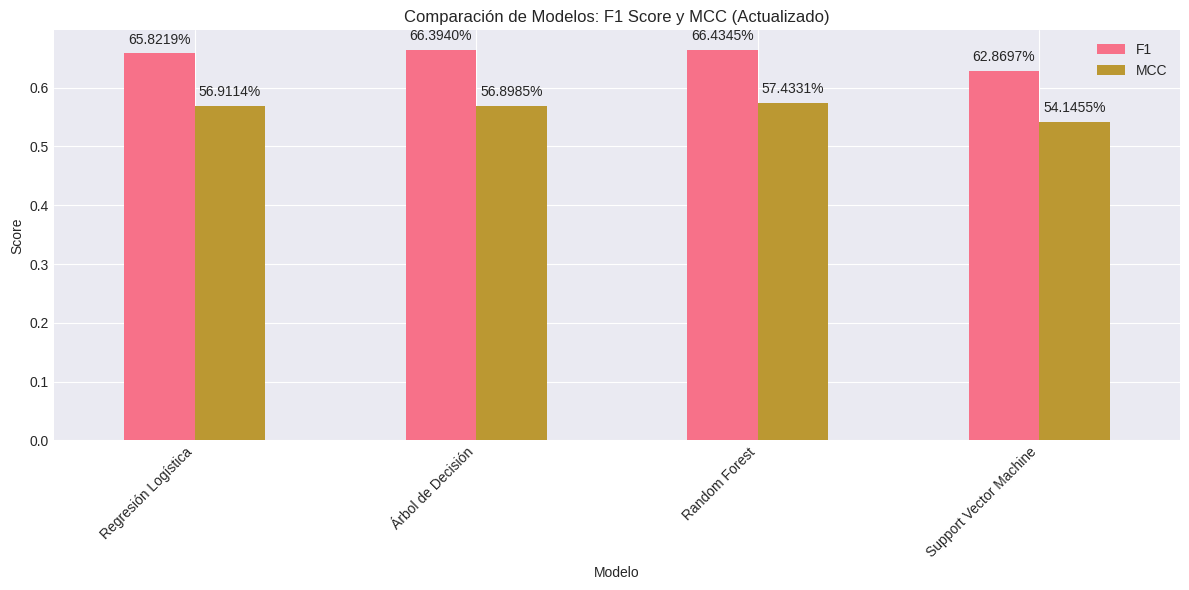

In [ ]:
#CELDA 67:
ax_updated = resultados_actualizados.set_index("Modelo")[["F1", "MCC"]].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparación de Modelos: F1 Score y MCC (Actualizado)")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')

for container in ax_updated.containers:
    for p in container.patches:
        ax_updated.annotate(f'{p.get_height():.4%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

Basándonos en la métrica F1-Score, el modelo 'Random Forest' tuvo el mejor rendimiento, seguido por 'Árbol de Decisión' y 'Regresión Logística'.

In [ ]:
# CELDA 68: VALIDACIÓN CRUZADA (CROSS VALIDATION)

from sklearn.model_selection import cross_val_score
import pandas as pd

modelos = {
    "Regresión Logística": modelo_lr,
    "Árbol de Decisión": modelo_tree,
    "Random Forest": modelo_rf,
    "Support Vector Machine": modelo_svm
}

cv_resultados = []

for nombre, modelo in modelos.items():

    scores = cross_val_score(
        modelo,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )

    cv_resultados.append({
        "Modelo": nombre,
        "F1 Promedio": scores.mean(),
        "Desv. Estándar": scores.std()
    })

cv_resultados = pd.DataFrame(cv_resultados)

display(cv_resultados.sort_values("F1 Promedio", ascending=False))

,Modelo,F1 Promedio,Desv. Estándar
2,Random Forest,0.684028,0.005733
1,Árbol de Decisión,0.673843,0.008150
0,Regresión Logística,0.657416,0.008456
3,Support Vector Machine,0.646721,0.005612


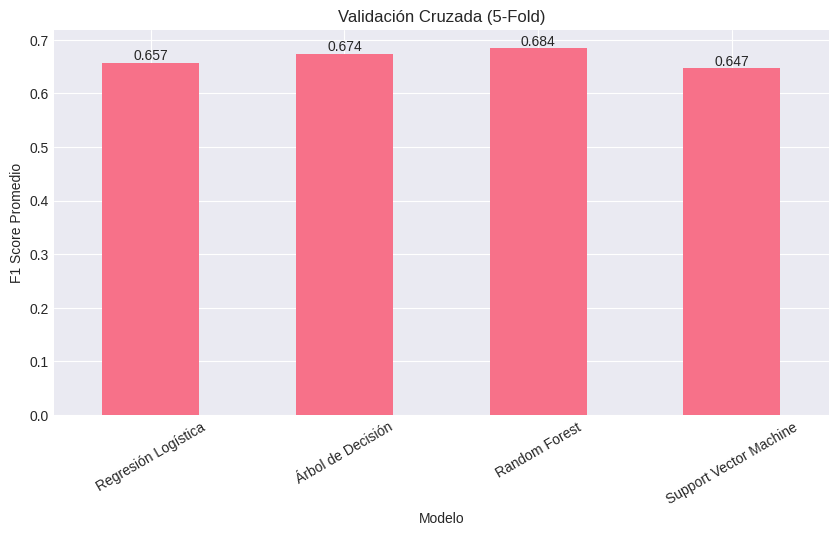

In [ ]:
# CELDA 69: GRÁFICO CROSS VALIDATION

import matplotlib.pyplot as plt

ax = cv_resultados.set_index("Modelo")["F1 Promedio"].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Validación Cruzada (5-Fold)")
plt.ylabel("F1 Score Promedio")
plt.xticks(rotation=30)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.3f}",
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.show()

--- Regresión Logística: Evaluación Detallada ---
CV promedio Accuracy: 0.8496 (+/- 0.0035)
CV promedio F1 Score: 0.6574 (+/- 0.0085)
Train accuracy: 0.8525
Test accuracy: 0.8508

--- Métricas Completas en Conjunto de Entrenamiento (Regresión Logística) ---
Accuracy (Train): 0.8525
Precision (Train): 0.7352
Recall (Train): 0.6058
F1 Score (Train): 0.6643

--- Métricas Completas en Conjunto de Prueba (Regresión Logística) ---
Accuracy (Test): 0.8508
Precision (Test): 0.7345
Recall (Test): 0.5963
F1 Score (Test): 0.6582

--- Reporte de clasificación (Test - Regresión Logística) ---
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4940
           1       0.73      0.60      0.66      1568

    accuracy                           0.85      6508
   macro avg       0.81      0.76      0.78      6508
weighted avg       0.84      0.85      0.85      6508


--- Matriz de confusión (Test - Regresión Logística) ---


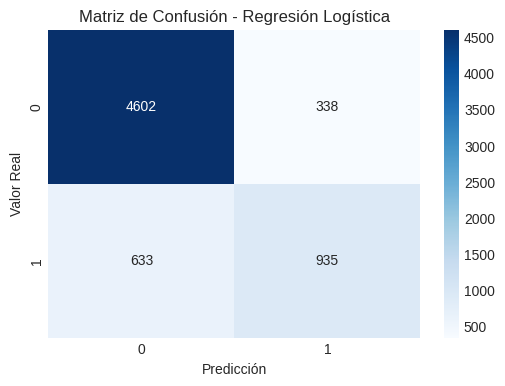

In [ ]:
print("--- Regresión Logística: Evaluación Detallada ---")

# 1. Validación cruzada (5 folds)
# Accuracy
scores_lr_acc = cross_val_score(modelo_lr, X_train, y_train, cv=5, scoring='accuracy')
print(f"CV promedio Accuracy: {scores_lr_acc.mean():.4f} (+/- {scores_lr_acc.std():.4f})")

# F1 Score
scores_lr_f1 = cross_val_score(modelo_lr, X_train, y_train, cv=5, scoring='f1')
print(f"CV promedio F1 Score: {scores_lr_f1.mean():.4f} (+/- {scores_lr_f1.std():.4f})")

# 2. Entrenar con todo el conjunto de entrenamiento
# Note: modelo_lr is already fitted, this is for reproducibility if running from scratch.
modelo_lr.fit(X_train, y_train)

# 3. Evaluar en entrenamiento
y_train_pred_lr = modelo_lr.predict(X_train)
print(f"Train accuracy: {accuracy_score(y_train, y_train_pred_lr):.4f}")

# 4. Evaluar en prueba
y_test_pred_lr = modelo_lr.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_test_pred_lr):.4f}")

print("\n--- Métricas Completas en Conjunto de Entrenamiento (Regresión Logística) ---")
print(f"Accuracy (Train): {accuracy_score(y_train, y_train_pred_lr):.4f}")
print(f"Precision (Train): {precision_score(y_train, y_train_pred_lr):.4f}")
print(f"Recall (Train): {recall_score(y_train, y_train_pred_lr):.4f}")
print(f"F1 Score (Train): {f1_score(y_train, y_train_pred_lr):.4f}")

print("\n--- Métricas Completas en Conjunto de Prueba (Regresión Logística) ---")
print(f"Accuracy (Test): {accuracy_score(y_test, y_test_pred_lr):.4f}")
print(f"Precision (Test): {precision_score(y_test, y_test_pred_lr):.4f}")
print(f"Recall (Test): {recall_score(y_test, y_test_pred_lr):.4f}")
print(f"F1 Score (Test): {f1_score(y_test, y_test_pred_lr):.4f}")

# 5. Reporte de clasificación detallado (Test)
print("\n--- Reporte de clasificación (Test - Regresión Logística) ---")
print(classification_report(y_test, y_test_pred_lr))

# 6. Matriz de confusión (Test)
print("\n--- Matriz de confusión (Test - Regresión Logística) ---")
cm_lr_detailed = confusion_matrix(y_test, y_test_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr_detailed, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

--- Árbol de Decisión: Evaluación Detallada ---
CV promedio Accuracy: 0.8571 (+/- 0.0045)
CV promedio F1 Score: 0.6738 (+/- 0.0081)
Train accuracy: 0.8750
Test accuracy: 0.8485

--- Métricas Completas en Conjunto de Entrenamiento (Árbol de Decisión) ---
Accuracy (Train): 0.8750
Precision (Train): 0.7707
Recall (Train): 0.6849
F1 Score (Train): 0.7253

--- Métricas Completas en Conjunto de Prueba (Árbol de Decisión) ---
Accuracy (Test): 0.8485
Precision (Test): 0.7130
Recall (Test): 0.6212
F1 Score (Test): 0.6639

--- Reporte de clasificación (Test - Árbol de Decisión) ---
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4940
           1       0.71      0.62      0.66      1568

    accuracy                           0.85      6508
   macro avg       0.80      0.77      0.78      6508
weighted avg       0.84      0.85      0.84      6508


--- Matriz de confusión (Test - Árbol de Decisión) ---


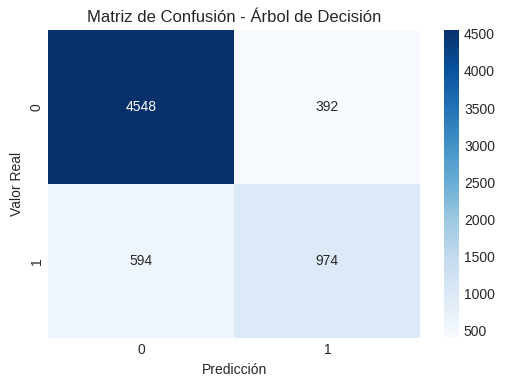

In [ ]:
print("--- Árbol de Decisión: Evaluación Detallada ---")

# 1. Validación cruzada (5 folds)
# Accuracy
scores_tree_acc = cross_val_score(modelo_tree, X_train, y_train, cv=5, scoring='accuracy')
print(f"CV promedio Accuracy: {scores_tree_acc.mean():.4f} (+/- {scores_tree_acc.std():.4f})")

# F1 Score
scores_tree_f1 = cross_val_score(modelo_tree, X_train, y_train, cv=5, scoring='f1')
print(f"CV promedio F1 Score: {scores_tree_f1.mean():.4f} (+/- {scores_tree_f1.std():.4f})")

# 2. Entrenar con todo el conjunto de entrenamiento
# Note: modelo_tree is already fitted, this is for reproducibility if running from scratch.
modelo_tree.fit(X_train, y_train)

# 3. Evaluar en entrenamiento
y_train_pred_tree = modelo_tree.predict(X_train)
print(f"Train accuracy: {accuracy_score(y_train, y_train_pred_tree):.4f}")

# 4. Evaluar en prueba
y_test_pred_tree = modelo_tree.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_test_pred_tree):.4f}")

print("\n--- Métricas Completas en Conjunto de Entrenamiento (Árbol de Decisión) ---")
print(f"Accuracy (Train): {accuracy_score(y_train, y_train_pred_tree):.4f}")
print(f"Precision (Train): {precision_score(y_train, y_train_pred_tree):.4f}")
print(f"Recall (Train): {recall_score(y_train, y_train_pred_tree):.4f}")
print(f"F1 Score (Train): {f1_score(y_train, y_train_pred_tree):.4f}")

print("\n--- Métricas Completas en Conjunto de Prueba (Árbol de Decisión) ---")
print(f"Accuracy (Test): {accuracy_score(y_test, y_test_pred_tree):.4f}")
print(f"Precision (Test): {precision_score(y_test, y_test_pred_tree):.4f}")
print(f"Recall (Test): {recall_score(y_test, y_test_pred_tree):.4f}")
print(f"F1 Score (Test): {f1_score(y_test, y_test_pred_tree):.4f}")

# 5. Reporte de clasificación detallado (Test)
print("\n--- Reporte de clasificación (Test - Árbol de Decisión) ---")
print(classification_report(y_test, y_test_pred_tree))

# 6. Matriz de confusión (Test)
print("\n--- Matriz de confusión (Test - Árbol de Decisión) ---")
cm_tree_detailed = confusion_matrix(y_test, y_test_pred_tree)
plt.figure(figsize=(6,4))
sns.heatmap(cm_tree_detailed, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

--- Random Forest: Evaluación Detallada ---
CV promedio Accuracy: 0.8589 (+/- 0.0035)
CV promedio F1 Score: 0.6840 (+/- 0.0057)
Train accuracy: 1.0000
Test accuracy: 0.8519

--- Métricas Completas en Conjunto de Entrenamiento (Random Forest) ---
Accuracy (Train): 1.0000
Precision (Train): 1.0000
Recall (Train): 1.0000
F1 Score (Train): 1.0000

--- Métricas Completas en Conjunto de Prueba (Random Forest) ---
Accuracy (Test): 0.8519
Precision (Test): 0.7316
Recall (Test): 0.6084
F1 Score (Test): 0.6643

--- Reporte de clasificación (Test - Random Forest) ---
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4940
           1       0.73      0.61      0.66      1568

    accuracy                           0.85      6508
   macro avg       0.81      0.77      0.78      6508
weighted avg       0.85      0.85      0.85      6508


--- Matriz de confusión (Test - Random Forest) ---


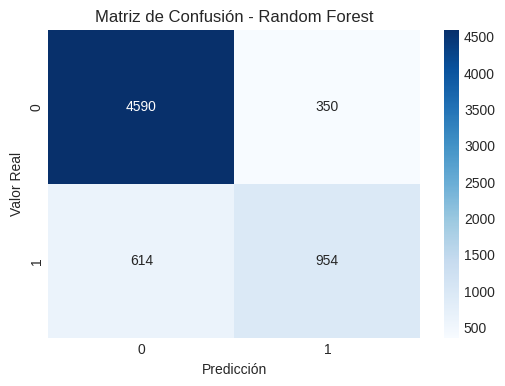

In [ ]:
print("--- Random Forest: Evaluación Detallada ---")

# 1. Validación cruzada (5 folds)
# Accuracy
scores_rf_acc = cross_val_score(modelo_rf, X_train, y_train, cv=5, scoring='accuracy')
print(f"CV promedio Accuracy: {scores_rf_acc.mean():.4f} (+/- {scores_rf_acc.std():.4f})")

# F1 Score
scores_rf_f1 = cross_val_score(modelo_rf, X_train, y_train, cv=5, scoring='f1')
print(f"CV promedio F1 Score: {scores_rf_f1.mean():.4f} (+/- {scores_rf_f1.std():.4f})")

# 2. Entrenar con todo el conjunto de entrenamiento
# Note: modelo_rf is already fitted, this is for reproducibility if running from scratch.
modelo_rf.fit(X_train, y_train)

# 3. Evaluar en entrenamiento
y_train_pred_rf = modelo_rf.predict(X_train)
print(f"Train accuracy: {accuracy_score(y_train, y_train_pred_rf):.4f}")

# 4. Evaluar en prueba
y_test_pred_rf = modelo_rf.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_test_pred_rf):.4f}")

print("\n--- Métricas Completas en Conjunto de Entrenamiento (Random Forest) ---")
print(f"Accuracy (Train): {accuracy_score(y_train, y_train_pred_rf):.4f}")
print(f"Precision (Train): {precision_score(y_train, y_train_pred_rf):.4f}")
print(f"Recall (Train): {recall_score(y_train, y_train_pred_rf):.4f}")
print(f"F1 Score (Train): {f1_score(y_train, y_train_pred_rf):.4f}")

print("\n--- Métricas Completas en Conjunto de Prueba (Random Forest) ---")
print(f"Accuracy (Test): {accuracy_score(y_test, y_test_pred_rf):.4f}")
print(f"Precision (Test): {precision_score(y_test, y_test_pred_rf):.4f}")
print(f"Recall (Test): {recall_score(y_test, y_test_pred_rf):.4f}")
print(f"F1 Score (Test): {f1_score(y_test, y_test_pred_rf):.4f}")

# 5. Reporte de clasificación detallado (Test)
print("\n--- Reporte de clasificación (Test - Random Forest) ---")
print(classification_report(y_test, y_test_pred_rf))

# 6. Matriz de confusión (Test)
print("\n--- Matriz de confusión (Test - Random Forest) ---")
cm_rf_detailed = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf_detailed, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

--- Support Vector Machine (SVM): Evaluación Detallada ---
CV promedio Accuracy: 0.8492 (+/- 0.0021)
CV promedio F1 Score: 0.6467 (+/- 0.0056)
Train accuracy: 0.8598
Test accuracy: 0.8437

--- Métricas Completas en Conjunto de Entrenamiento (SVM) ---
Accuracy (Train): 0.8598
Precision (Train): 0.7658
Recall (Train): 0.6026
F1 Score (Train): 0.6745

--- Métricas Completas en Conjunto de Prueba (SVM) ---
Accuracy (Test): 0.8437
Precision (Test): 0.7353
Recall (Test): 0.5491
F1 Score (Test): 0.6287

--- Reporte de clasificación (Test - SVM) ---
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      4940
           1       0.74      0.55      0.63      1568

    accuracy                           0.84      6508
   macro avg       0.80      0.74      0.76      6508
weighted avg       0.84      0.84      0.84      6508


--- Matriz de confusión (Test - SVM) ---


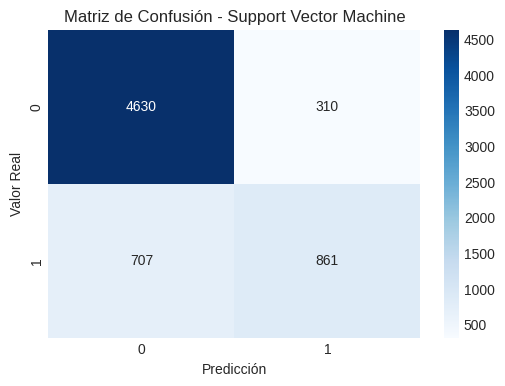

In [ ]:
print("--- Support Vector Machine (SVM): Evaluación Detallada ---")

# 1. Validación cruzada (5 folds)
# Accuracy
scores_svm_acc = cross_val_score(modelo_svm, X_train, y_train, cv=5, scoring='accuracy')
print(f"CV promedio Accuracy: {scores_svm_acc.mean():.4f} (+/- {scores_svm_acc.std():.4f})")

# F1 Score
scores_svm_f1 = cross_val_score(modelo_svm, X_train, y_train, cv=5, scoring='f1')
print(f"CV promedio F1 Score: {scores_svm_f1.mean():.4f} (+/- {scores_svm_f1.std():.4f})")

# 2. Entrenar con todo el conjunto de entrenamiento
# Note: modelo_svm is already fitted, this is for reproducibility if running from scratch.
modelo_svm.fit(X_train, y_train)

# 3. Evaluar en entrenamiento
y_train_pred_svm = modelo_svm.predict(X_train)
print(f"Train accuracy: {accuracy_score(y_train, y_train_pred_svm):.4f}")

# 4. Evaluar en prueba
y_test_pred_svm = modelo_svm.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_test_pred_svm):.4f}")

print("\n--- Métricas Completas en Conjunto de Entrenamiento (SVM) ---")
print(f"Accuracy (Train): {accuracy_score(y_train, y_train_pred_svm):.4f}")
print(f"Precision (Train): {precision_score(y_train, y_train_pred_svm):.4f}")
print(f"Recall (Train): {recall_score(y_train, y_train_pred_svm):.4f}")
print(f"F1 Score (Train): {f1_score(y_train, y_train_pred_svm):.4f}")

print("\n--- Métricas Completas en Conjunto de Prueba (SVM) ---")
print(f"Accuracy (Test): {accuracy_score(y_test, y_test_pred_svm):.4f}")
print(f"Precision (Test): {precision_score(y_test, y_test_pred_svm):.4f}")
print(f"Recall (Test): {recall_score(y_test, y_test_pred_svm):.4f}")
print(f"F1 Score (Test): {f1_score(y_test, y_test_pred_svm):.4f}")

# 5. Reporte de clasificación detallado (Test)
print("\n--- Reporte de clasificación (Test - SVM) ---")
print(classification_report(y_test, y_test_pred_svm))

# 6. Matriz de confusión (Test)
print("\n--- Matriz de confusión (Test - SVM) ---")
cm_svm_detailed = confusion_matrix(y_test, y_test_pred_svm)
plt.figure(figsize=(6,4))
sns.heatmap(cm_svm_detailed, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - Support Vector Machine")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()